# Exploratory Data Analysis (EDA)

## 1. Necessary Libraries Installation

In [1]:
# Installing the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

print("Libraries imported successfully")

Libraries imported successfully


## 2. Dataset Loading & Understanding

In [2]:
# Loading the Dataset
# Read dataset from data folder
df = pd.read_csv("../data/engine_data.csv")

# Display first 5 records
df.head()

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine Condition
0,700,2.493592,11.790927,3.178981,84.144163,81.632187,1
1,876,2.941606,16.193866,2.464504,77.640934,82.445724,0
2,520,2.961746,6.553147,1.064347,77.752266,79.645777,1
3,473,3.707835,19.510172,3.727455,74.129907,71.774629,1
4,619,5.672919,15.738871,2.052251,78.396989,87.000225,0


In [3]:
# Understanding Dataset Dimensions
print(df.shape)

(19535, 7)


In [4]:
# Displaying Column Names
print(df.columns.tolist())

['Engine rpm', 'Lub oil pressure', 'Fuel pressure', 'Coolant pressure', 'lub oil temp', 'Coolant temp', 'Engine Condition']


## 3. Data Quality Checks

In [5]:
# Checking Missing Values
df.isnull().sum()

Engine rpm          0
Lub oil pressure    0
Fuel pressure       0
Coolant pressure    0
lub oil temp        0
Coolant temp        0
Engine Condition    0
dtype: int64

In [6]:
# Checking Duplicate Records
df.duplicated().sum()

np.int64(0)

In [7]:
# Statistical Summary of Numerical Features
df.describe()

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine Condition
count,19535.000000,19535.000000,19535.000000,19535.000000,19535.000000,19535.000000,19535.000000
mean,791.239263,3.303775,6.655615,2.335369,77.643420,78.427433,0.630509
std,267.611193,1.021643,2.761021,1.036382,3.110984,6.206749,0.482679
min,61.000000,0.003384,0.003187,0.002483,71.321974,61.673325,0.000000
25%,593.000000,2.518815,4.916886,1.600466,75.725990,73.895421,0.000000
50%,746.000000,3.162035,6.201720,2.166883,76.817350,78.346662,1.000000
75%,934.000000,4.055272,7.744973,2.848840,78.071691,82.915411,1.000000
max,2239.000000,7.265566,21.138326,7.478505,89.580796,195.527912,1.000000


**Observations**:

- The dataset contains 19,535 records and 7 features.
- No missing values are present in the dataset.
- No duplicate records were identified.
- All features are numerical in nature.
- Engine Condition appears to be the target variable with binary values (0 and 1).

## 4. Univariate Analysis

In [8]:
# Checking Target Variable Distribution

# Display count of target classes
print(df["Engine Condition"].value_counts())

Engine Condition
1    12317
0     7218
Name: count, dtype: int64


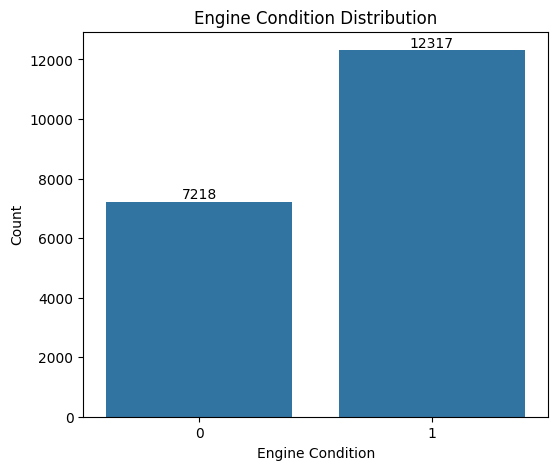

In [9]:
# Visualizing Target Variable Distribution

plt.figure(figsize=(6,5))

ax = sns.countplot(
    x="Engine Condition",
    data=df
)

# Add data labels
for container in ax.containers:
    ax.bar_label(container)

plt.title("Engine Condition Distribution")
plt.xlabel("Engine Condition")
plt.ylabel("Count")

plt.show()

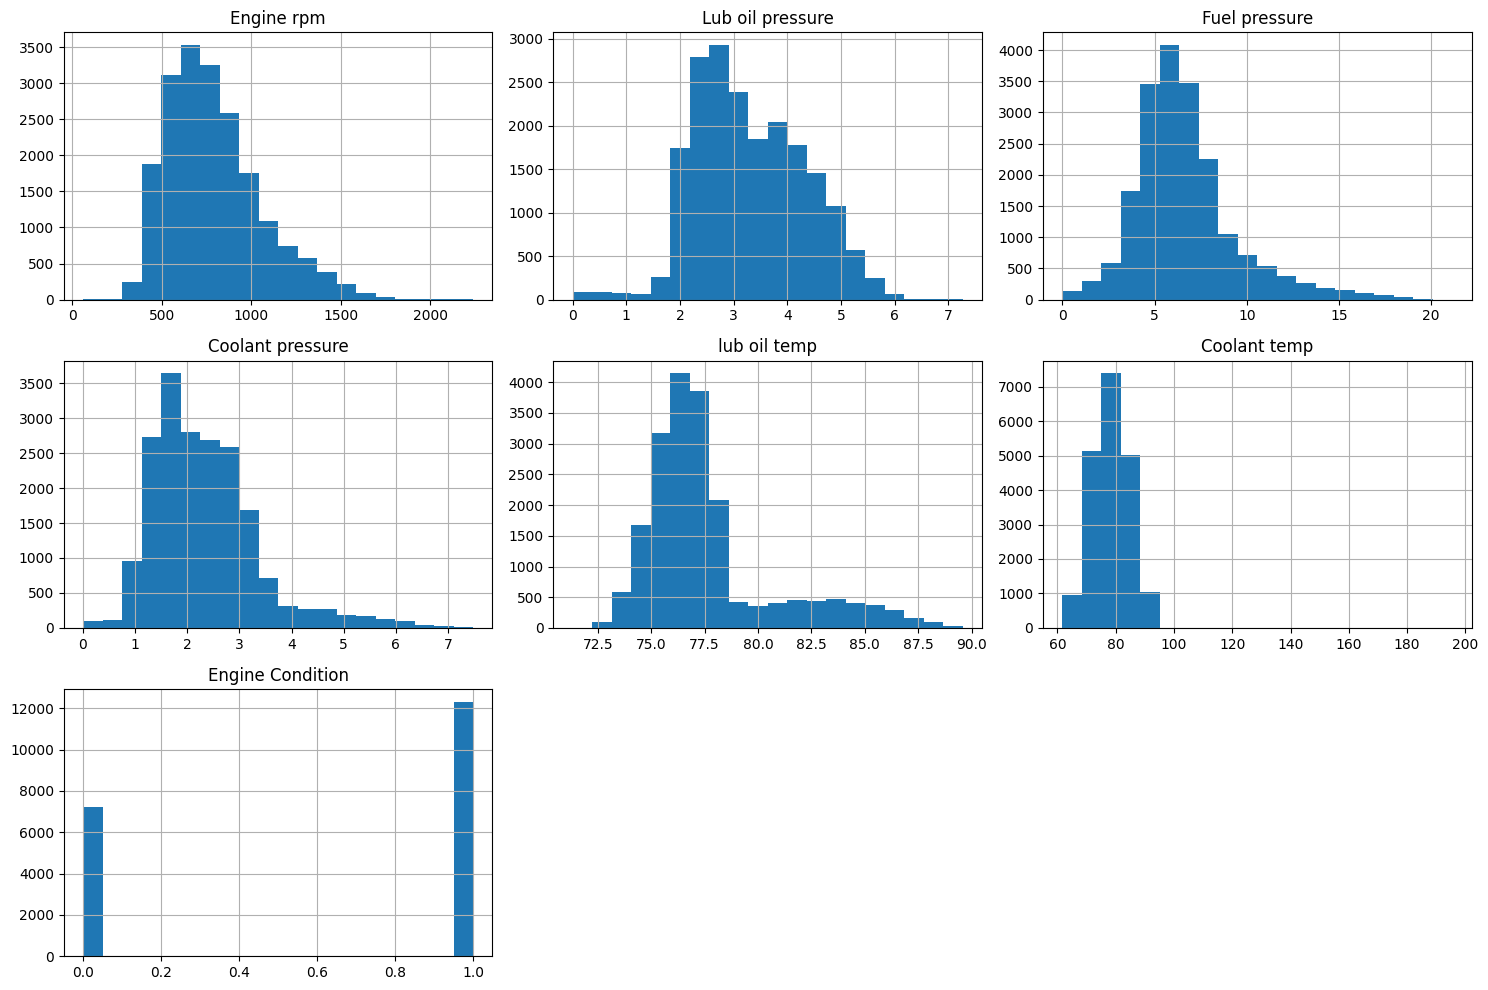

In [10]:
# Distribution of Numerical Features

df.hist(
    figsize=(15,10),
    bins=20
)

plt.tight_layout()

plt.show()

**Observations**:

- The target variable `Engine Condition` shows a moderate class imbalance.
- Class `1` (Normal Operating Condition) contains 12,317 records (~63.05%).
- Class `0` (Requires Maintenance) contains 7,218 records (~36.95%).
- The dataset is not severely imbalanced, but class distribution should be considered during model evaluation.
- Most numerical features such as `Engine rpm`, `Fuel pressure`, `Lub oil pressure`, and `Coolant pressure` show positively skewed distributions.
- `Lub oil temp` and `Coolant temp` appear more concentrated around specific ranges with a few extreme values.
- Certain features indicate the presence of potential outliers which require further investigation during outlier analysis.

## 5. Bivariate Analysis


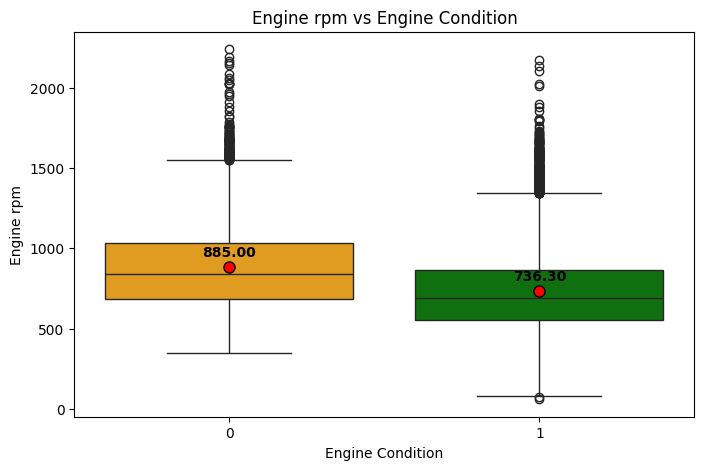

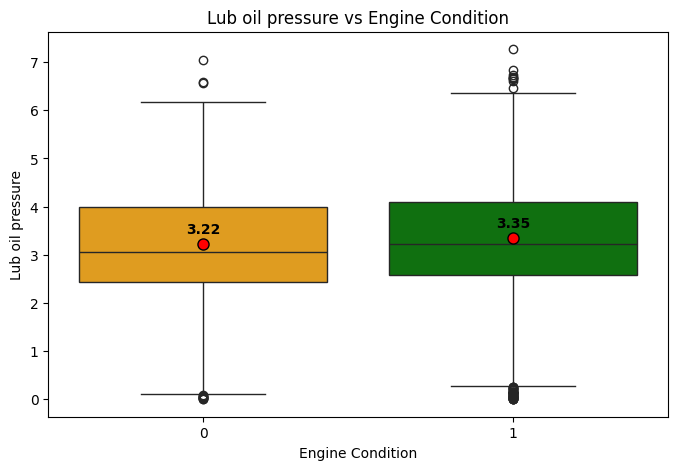

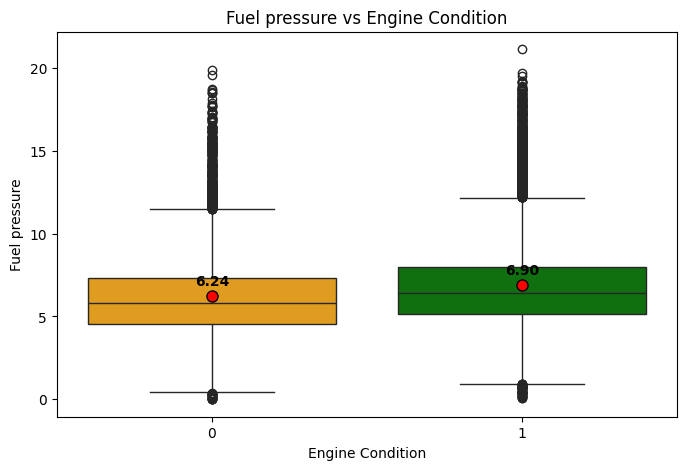

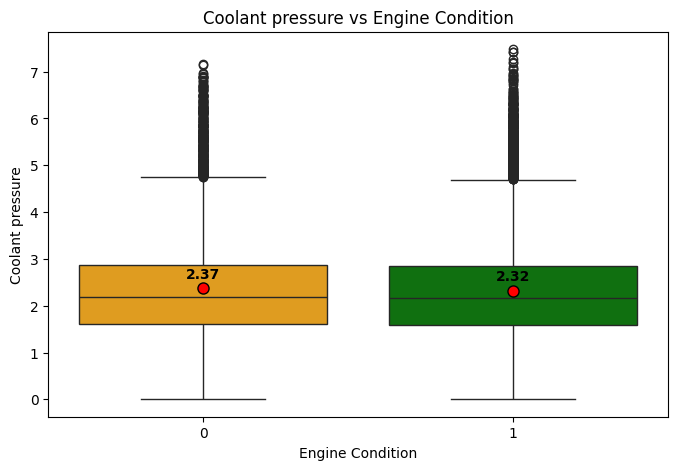

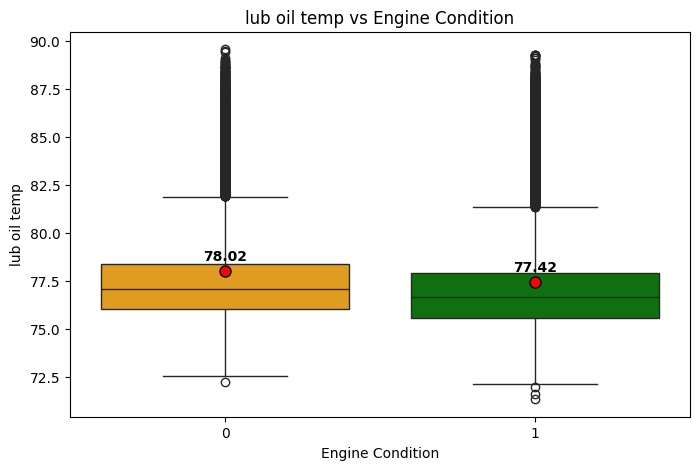

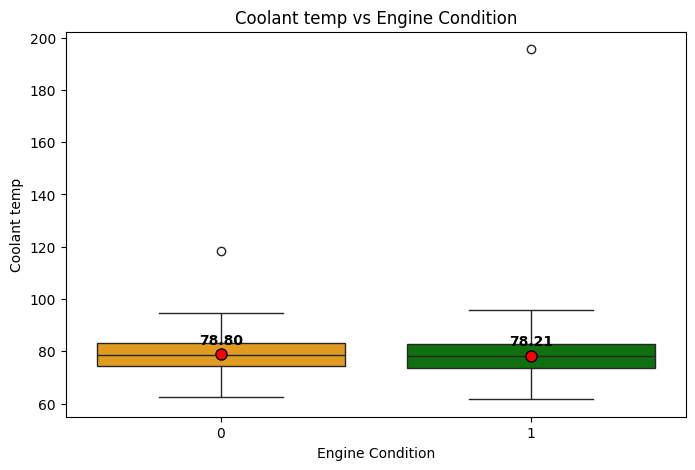

In [11]:
# Features for Bivariate Analysis

features = [
    "Engine rpm",
    "Lub oil pressure",
    "Fuel pressure",
    "Coolant pressure",
    "lub oil temp",
    "Coolant temp"
]

# Creating boxplots for all features

for feature in features:

    plt.figure(figsize=(8,5))

    ax = sns.boxplot(
        x="Engine Condition",
        y=feature,
        hue="Engine Condition",
        data=df,
        palette=["orange","green"],
        legend=False,
        showmeans=True,
        meanprops={
            "marker":"o",
            "markerfacecolor":"red",
            "markeredgecolor":"black",
            "markersize":"8"
        }
    )

    # Mean values
    mean_values = df.groupby("Engine Condition")[feature].mean()

    # Mean labels
    for i, mean in enumerate(mean_values):

        offset = (df[feature].max()-df[feature].min())*0.03

        plt.text(
            i,
            mean + offset,
            f"{mean:.2f}",
            ha='center',
            fontweight='bold'
        )

    plt.title(f"{feature} vs Engine Condition")
    plt.xlabel("Engine Condition")
    plt.ylabel(feature)

    plt.show()

**Observations**:

- Engine RPM shows noticeable variation between the two engine conditions.

- The mean Engine RPM differs between the two engine condition classes:
  - Class 0 mean ≈ 885
  - Class 1 mean ≈ 736
- This suggests that Engine RPM may contribute to distinguishing between target clase
s.
s.
- Lub oil pressure shows a slight increase in class `1` compared to class `0`, though overlap exists between both classes.

- Fuel pressure displays a visible shift between classes:
  - Class `0` mean ≈ 6.24
  - Class `1` mean ≈ 6.90
  This feature may have predictive importance.

- Coolant pressure exhibits very similar distributions between classes with minimal mean difference.

- Lub oil temperature and Coolant temperature show nearly identical distributions between both engine conditions, suggesting weaker discriminatory power individually.

- Several features contain outliers across both classes, which will be further analyzed during Outlier Analysis.

- Features with clearer separation between classes (Engine RPM and Fuel Pressure) may contribute more significantly during model building.

## 6. Multivariate Analysis

In [12]:
# Creating sample dataset for multivariate analysis

sample_df = df.sample(
    n=1000,
    random_state=42
)
print("Note: A sample dataset was created because generating a pairplot on the full dataset would be computationally heavy.")

Note: A sample dataset was created because generating a pairplot on the full dataset would be computationally heavy.


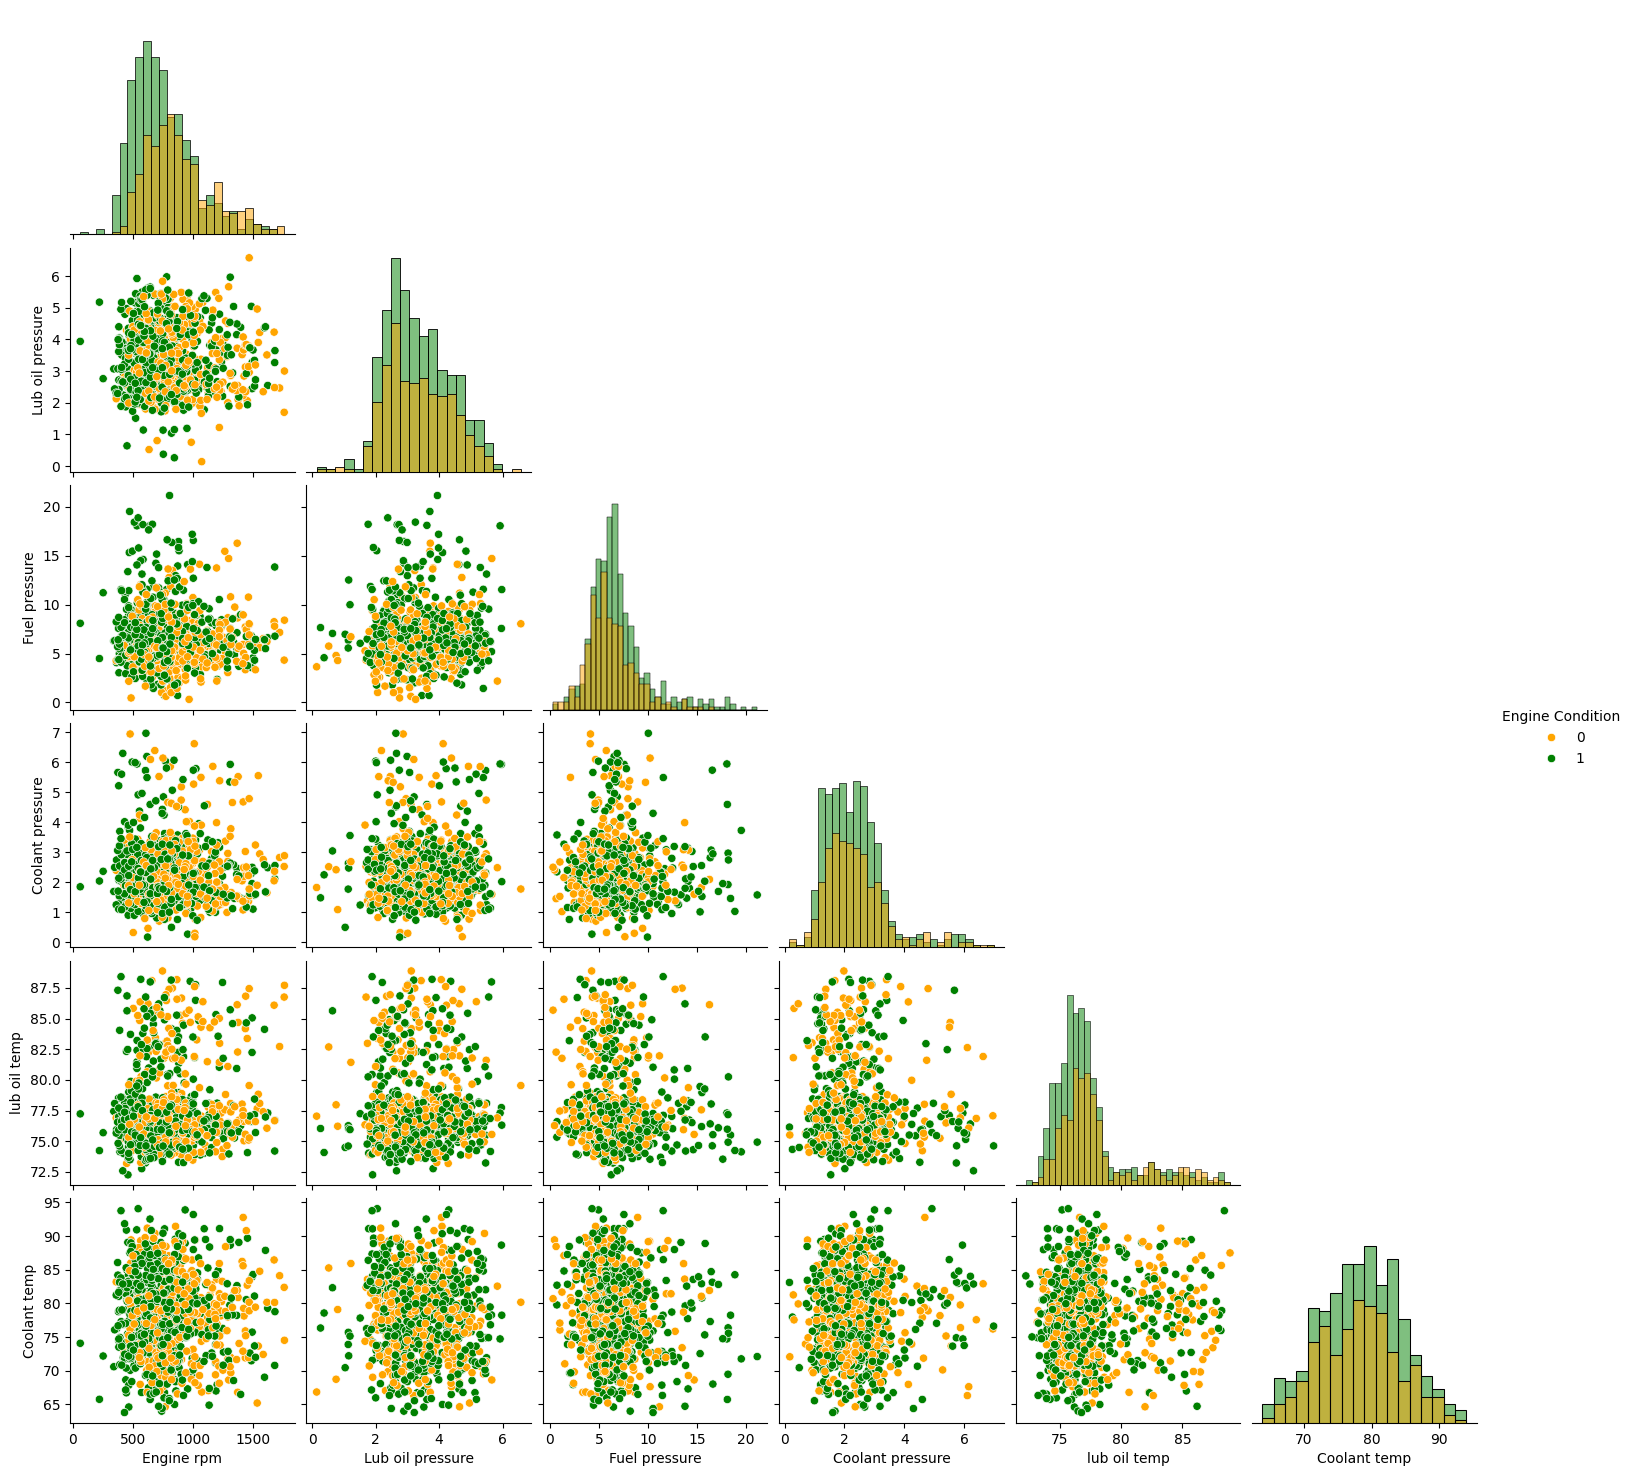

In [13]:
# Multivariate Analysis using Pairplot

sns.pairplot(
    sample_df,
    hue="Engine Condition",
    corner=True,
    diag_kind="hist",
    palette=["orange", "green"]
)

plt.show()

**Observations**

- Multivariate Analysis was performed using a pairplot to understand relationships among multiple numerical features simultaneously.

- Most feature pairs exhibit weak linear relationships, indicating low inter-feature dependency.

- Engine RPM and Fuel Pressure show relatively better class-level separation compared to other features.

- Significant overlap exists between the two engine condition classes across most feature combinations, suggesting that prediction will likely depend on combined feature interactions rather than a single dominant variable.

- The diagonal histograms indicate that several features exhibit skewed distributions and contain potential outliers.

- No strong clustering patterns were observed between the two engine condition classes.

- Overall, the dataset appears suitable for machine learning classification models capable of learning complex nonlinear relationships.

## 7. Correlation Analysis


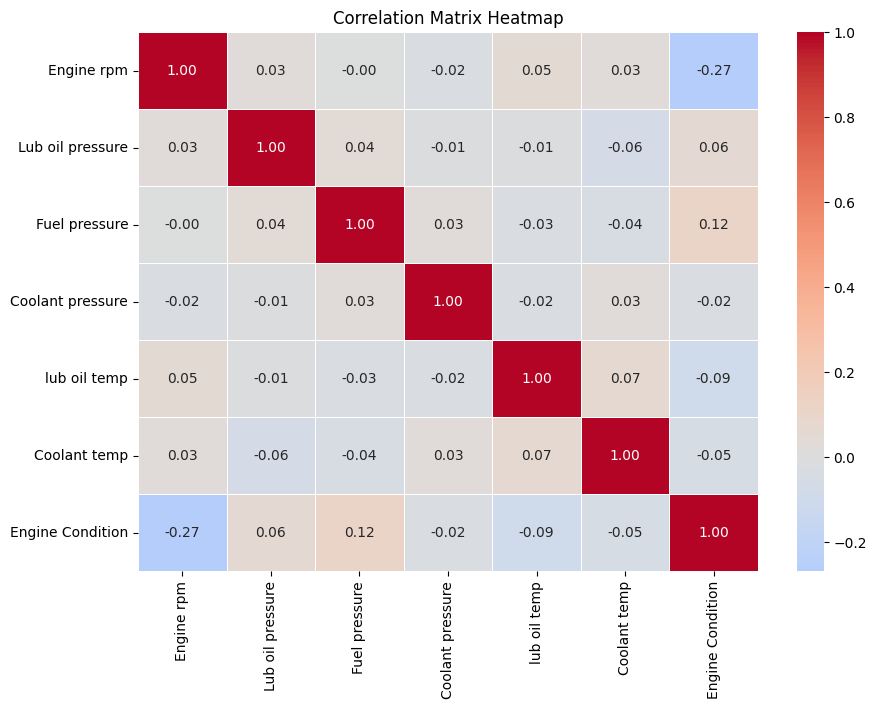

In [14]:
# Correlation Analysis

plt.figure(figsize=(10,7))

correlation_matrix = df.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix Heatmap")

plt.show()

**Observations**:

- Most features show weak correlations with each other, indicating low multicollinearity in the dataset.

- Engine RPM has the strongest correlation with Engine Condition (-0.27), suggesting it may be an important feature for prediction.

- Fuel pressure shows a small positive correlation (0.12) with Engine Condition.

- Lub oil temperature (-0.09) and Coolant temperature (-0.05) exhibit weak negative correlations with the target variable.

- Coolant pressure shows almost no correlation with Engine Condition (-0.02), indicating limited linear relationship individually.

- Since no pair of features exhibits very high correlation, all features can initially be retained for model building.

- Overall, the dataset does not appear to suffer from strong multicollinearity issues.

## 8. Outlier Analysis

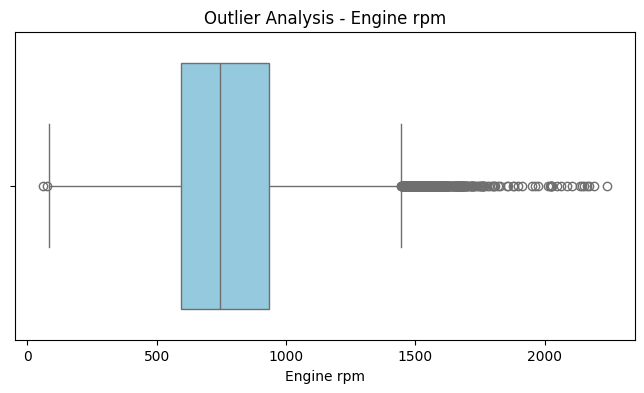

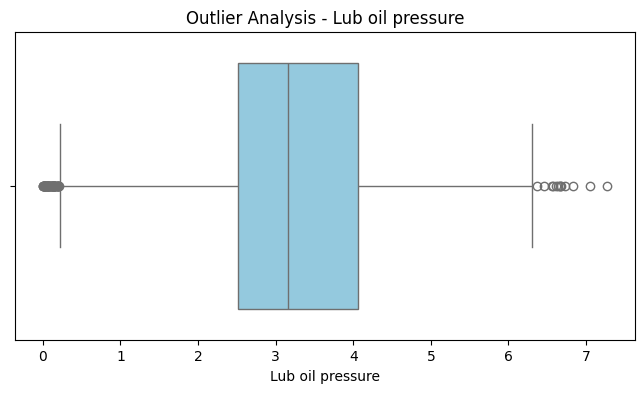

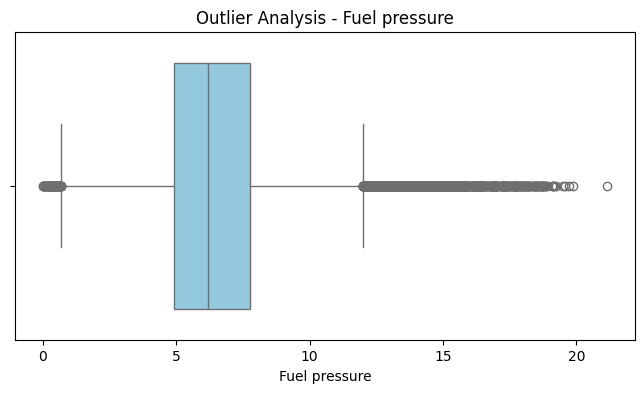

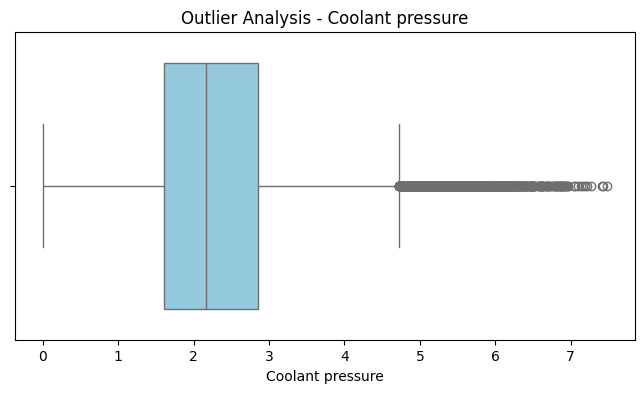

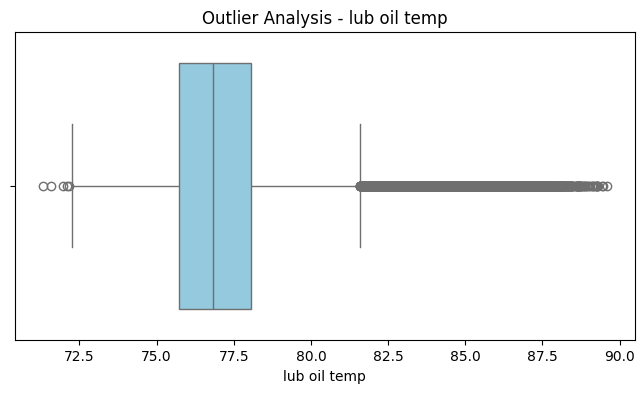

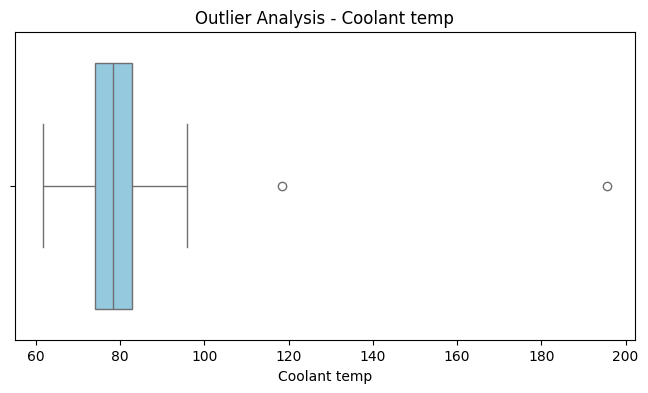

In [15]:
# Outlier Analysis using Boxplots

features = [
    "Engine rpm",
    "Lub oil pressure",
    "Fuel pressure",
    "Coolant pressure",
    "lub oil temp",
    "Coolant temp"
]

# Creating boxplots for outlier analysis

for feature in features:

    plt.figure(figsize=(8,4))

    sns.boxplot(
        x=df[feature],
        color="skyblue"
    )

    plt.title(f"Outlier Analysis - {feature}")

    plt.xlabel(feature)

    plt.show()

**Observations**:

- Most numerical features contain noticeable outliers on the higher end of the distribution.

- Engine RPM shows several extreme high-value outliers above the upper whisker, indicating possible abnormal operating conditions.

- Fuel pressure and Coolant pressure also contain multiple upper-end outliers, suggesting occasional unusually high pressure readings.

- Lub oil pressure contains comparatively fewer outliers than other pressure-related features.

- Lub oil temperature exhibits many upper-end outliers concentrated between approximately 82 and 90.

- Coolant temperature contains a few extreme outliers, including values significantly higher than the normal operating range.

- Presence of outliers may influence model performance and should be considered during data preparation and model selection.

- Since tree-based models such as Random Forest and XGBoost are generally robust to outliers, immediate removal may not be necessary.

## 9. Final EDA Summary

- The dataset contains 19,535 records and 7 features, including the target variable `Engine Condition`.

- Data Quality Checks confirmed that the dataset contains no missing values or duplicate records.

- Univariate Analysis revealed that most numerical features exhibit positively skewed distributions with the presence of multiple outliers.

- Bivariate Analysis showed that features such as Engine RPM and Fuel Pressure demonstrate relatively stronger variation across engine condition classes compared to other variables.

- Multivariate Analysis indicated significant overlap between the target classes across several feature combinations, suggesting that engine condition prediction depends on combined feature interactions.

- Correlation Analysis revealed generally weak correlations among features, indicating low multicollinearity within the dataset.

- Outlier Analysis identified several upper-end outliers across multiple features. These outliers may represent abnormal engine operating conditions and were retained for further analysis.

- Overall, the dataset appears suitable for machine learning classification models with minimal preprocessing requirements.ng requirements.